# Genetic Algorithm for Constrained Optimisation:

**Author:** Phabel Antonio López Delgado, BSc.

This notebook demonstrates the application of a **Genetic Algorithm (GA)** to a real‑world constrained optimisation problem: formulating a nutritional bar that meets specific nutritional requirements while minimising cost.

We optimise the quantities of four ingredients (whey protein, oats, almond butter, sugar) to satisfy constraints on proteins, carbohydrates, fats, and calories, all within a given budget.

**Key Concepts Covered:**

- **Genetic Algorithm** – population‑based optimisation inspired by natural selection.
- **Fitness Function** – combines cost minimisation with penalty terms for constraint violations.
- **Selection** – tournament or roulette wheel selection based on fitness.
- **Crossover** – single‑point crossover to combine parent solutions.
- **Mutation** – random perturbation to maintain diversity.
- **Constraint Handling** – penalty approach for infeasible solutions.

**Key Techniques & Libraries:**
- `numpy` – numerical operations.
- `matplotlib` – visualisation of convergence.

**Objective:**
To understand how genetic algorithms can solve constrained optimisation problems where traditional gradient‑based methods are not applicable. The nutritional bar formulation serves as a practical case study.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("All imports successful.")

All imports successful.


## Problem Definition

We aim to formulate a nutritional bar using four ingredients:

| Ingredient | Cost per gram | Protein (g/100g) | Carbs (g/100g) | Fat (g/100g) | Calories (kcal/100g) |
|------------|---------------|------------------|----------------|--------------|----------------------|
| Whey Protein | $0.10 | 80 | 5 | 2 | 350 |
| Oats | $0.02 | 15 | 60 | 6 | 370 |
| Almond Butter | $0.15 | 25 | 20 | 50 | 600 |
| Sugar | $0.01 | 0 | 100 | 0 | 400 |

**Variables:**
- \( v_1 \): whey protein (g)
- \( v_2 \): oats (g)
- \( v_3 \): almond butter (g)
- \( v_4 \): sugar (g)

**Bounds:**
- Whey protein: 10 – 50 g
- Oats: 20 – 100 g
- Almond butter: 5 – 30 g
- Sugar: 0 – 20 g

**Constraints:**
- Protein ≥ 20 g
- Carbohydrates ≥ 30 g
- Fat ≥ 10 g
- Calories: 250 – 350 kcal

**Objective:**
Minimise total cost: \( C = 0.10v_1 + 0.02v_2 + 0.15v_3 + 0.01v_4 \)

In [2]:
# Ingredient data
ingredients = ['Whey Protein', 'Oats', 'Almond Butter', 'Sugar']
cost = np.array([0.10, 0.02, 0.15, 0.01])
protein = np.array([80, 15, 25, 0])      # g per 100g
carbs = np.array([5, 60, 20, 100])       # g per 100g
fat = np.array([2, 6, 50, 0])            # g per 100g
calories = np.array([350, 370, 600, 400]) # kcal per 100g

# Bounds for each ingredient
bounds_min = np.array([10, 20, 5, 0])
bounds_max = np.array([50, 100, 30, 20])

# Nutritional constraints
PROTEIN_MIN = 20
CARBS_MIN = 30
FAT_MIN = 10
CALORIES_MIN = 250
CALORIES_MAX = 350

n_ingredients = len(ingredients)

## Genetic Algorithm Implementation

We implement a genetic algorithm with the following components:

1. **Chromosome representation** – a vector of ingredient quantities.
2. **Fitness function** – minimises cost with penalties for constraint violations.
3. **Initialisation** – random solutions within bounds.
4. **Selection** – roulette wheel selection based on fitness.
5. **Crossover** – single‑point crossover.
6. **Mutation** – Gaussian perturbation with clipping to bounds.
7. **Elitism** – preserve the best solutions across generations.

In [3]:
class GeneticAlgorithm:
    """
    A genetic algorithm for constrained optimisation.
    """
    def __init__(self, n_variables, bounds_min, bounds_max,
                 population_size=50, generations=100,
                 crossover_prob=0.7, mutation_prob=0.2,
                 elite_size=2):
        self.n_variables = n_variables
        self.bounds_min = np.array(bounds_min)
        self.bounds_max = np.array(bounds_max)
        self.population_size = population_size
        self.generations = generations
        self.crossover_prob = crossover_prob
        self.mutation_prob = mutation_prob
        self.elite_size = elite_size
        self.history = []  # track best fitness per generation

    def _calculate_nutrition(self, chromosome):
        """Calculate total protein, carbs, fat, and calories for a solution."""
        grams_per_100 = chromosome / 100
        total_protein = np.sum(grams_per_100 * protein)
        total_carbs = np.sum(grams_per_100 * carbs)
        total_fat = np.sum(grams_per_100 * fat)
        total_calories = np.sum(grams_per_100 * calories)
        return total_protein, total_carbs, total_fat, total_calories

    def _fitness(self, chromosome):
        """
        Compute fitness = 1 / (cost + penalty).
        Penalty for each constraint violation.
        """
        p, c, f, cal = self._calculate_nutrition(chromosome)

        # Penalties (only for violations)
        penalty = 0.0
        penalty += max(0, PROTEIN_MIN - p) * 10
        penalty += max(0, CARBS_MIN - c) * 10
        penalty += max(0, FAT_MIN - f) * 10
        if cal < CALORIES_MIN:
            penalty += (CALORIES_MIN - cal) * 10
        elif cal > CALORIES_MAX:
            penalty += (cal - CALORIES_MAX) * 10

        total_cost = np.sum(chromosome * cost)

        # Avoid division by zero
        total = total_cost + penalty
        if total == 0:
            return 0.0
        return 1.0 / total

    def _initialise_population(self):
        """Create random initial population within bounds."""
        return np.random.uniform(
            self.bounds_min, self.bounds_max,
            (self.population_size, self.n_variables)
        )

    def _selection(self, population):
        """Roulette wheel selection based on fitness."""
        fitness_values = np.array([self._fitness(ind) for ind in population])
        total_fitness = np.sum(fitness_values)

        if total_fitness == 0:
            probabilities = np.ones(self.population_size) / self.population_size
        else:
            probabilities = fitness_values / total_fitness

        idx = np.random.choice(self.population_size, size=2, p=probabilities)
        return population[idx[0]], population[idx[1]]

    def _crossover(self, parent1, parent2):
        """Single‑point crossover."""
        if np.random.rand() < self.crossover_prob:
            point = np.random.randint(1, self.n_variables)
            child1 = np.concatenate((parent1[:point], parent2[point:]))
            child2 = np.concatenate((parent2[:point], parent1[point:]))
            return child1, child2
        return parent1.copy(), parent2.copy()

    def _mutation(self, individual):
        """Gaussian mutation with clipping to bounds."""
        if np.random.rand() < self.mutation_prob:
            idx = np.random.randint(self.n_variables)
            individual[idx] += np.random.normal(0, 1.0)
            individual = np.clip(individual, self.bounds_min, self.bounds_max)
        return individual

    def _get_best(self, population):
        """Return the best individual and its fitness."""
        fitness_values = [self._fitness(ind) for ind in population]
        best_idx = np.argmax(fitness_values)
        return population[best_idx], fitness_values[best_idx]

    def run(self, verbose=True):
        """
        Run the genetic algorithm.
        Returns the best solution, its fitness, and the history of best fitness.
        """
        population = self._initialise_population()
        self.history = []

        for gen in range(self.generations):
            # Elitism: keep the best solutions
            fitness_values = np.array([self._fitness(ind) for ind in population])
            elite_indices = np.argsort(fitness_values)[-self.elite_size:]
            elite = [population[i].copy() for i in elite_indices]

            # Create new population
            new_population = []
            while len(new_population) < self.population_size - self.elite_size:
                parent1, parent2 = self._selection(population)
                child1, child2 = self._crossover(parent1, parent2)
                child1 = self._mutation(child1)
                child2 = self._mutation(child2)
                new_population.extend([child1, child2])

            # Add elites
            new_population.extend(elite)
            population = np.array(new_population)

            # Track best
            best, best_fitness = self._get_best(population)
            self.history.append(best_fitness)

            if verbose and (gen % 10 == 0 or gen == self.generations - 1):
                print(f"Generation {gen+1}: Best fitness = {best_fitness:.6f}")

        best, best_fitness = self._get_best(population)
        return best, best_fitness, self.history

## Running the Genetic Algorithm

We run the GA with a population of 50 over 100 generations. The algorithm converges to a solution that satisfies all nutritional constraints while minimising cost.

In [4]:
# GA parameters
ga = GeneticAlgorithm(
    n_variables=n_ingredients,
    bounds_min=bounds_min,
    bounds_max=bounds_max,
    population_size=50,
    generations=100,
    crossover_prob=0.7,
    mutation_prob=0.2,
    elite_size=2
)

best_solution, best_fitness, history = ga.run(verbose=True)

Generation 1: Best fitness = 0.179075
Generation 11: Best fitness = 0.193310
Generation 21: Best fitness = 0.206056
Generation 31: Best fitness = 0.215329
Generation 41: Best fitness = 0.218039
Generation 51: Best fitness = 0.219012
Generation 61: Best fitness = 0.219730
Generation 71: Best fitness = 0.219730
Generation 81: Best fitness = 0.219763
Generation 91: Best fitness = 0.219971
Generation 100: Best fitness = 0.219971


In [6]:
# Display the optimal solution
print("\nOptimal solution found:")
for i, ingredient in enumerate(ingredients):
    print(f"  {ingredient}: {best_solution[i]:.2f} g")

# Nutritional information
protein_total, carbs_total, fat_total, calories_total = ga._calculate_nutrition(best_solution)
print("\nNutritional content:")
print(f"  Protein: {protein_total:.2f} g")
print(f"  Carbohydrates: {carbs_total:.2f} g")
print(f"  Fat: {fat_total:.2f} g")
print(f"  Calories: {calories_total:.2f} kcal")

total_cost = np.sum(best_solution * cost)
print(f"\nTotal cost: ${total_cost:.2f}")

# Check constraints
print("\nConstraint check:")
print(f"  Protein ≥ 20: {protein_total:.2f} g {'|Good' if protein_total >= PROTEIN_MIN else '|Bad'}")
print(f"  Carbs ≥ 30: {carbs_total:.2f} g {'|Good' if carbs_total >= CARBS_MIN else '|Bad'}")
print(f"  Fat ≥ 10: {fat_total:.2f} g {'|Good' if fat_total >= FAT_MIN else '|Bad'}")
print(f"  Calories: {calories_total:.2f} kcal {'|Good' if CALORIES_MIN <= calories_total <= CALORIES_MAX else '✗'}")


Optimal solution found:
  Whey Protein: 14.80 g
  Oats: 27.60 g
  Almond Butter: 16.11 g
  Sugar: 9.68 g

Nutritional content:
  Protein: 20.01 g
  Carbohydrates: 30.20 g
  Fat: 10.01 g
  Calories: 289.31 kcal

Total cost: $4.55

Constraint check:
  Protein ≥ 20: 20.01 g |Good
  Carbs ≥ 30: 30.20 g |Good
  Fat ≥ 10: 10.01 g |Good
  Calories: 289.31 kcal |Good


## Convergence Analysis

We plot the best fitness value across generations to observe how the algorithm converges to the optimal solution.

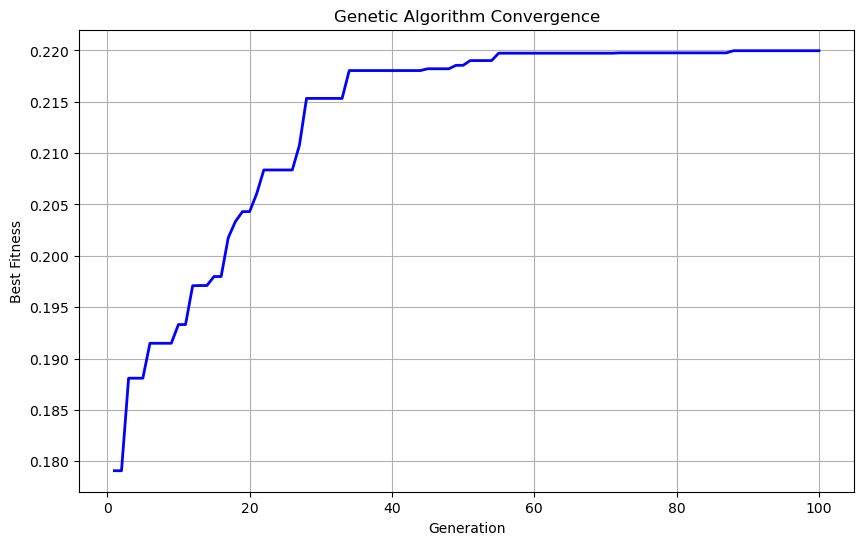

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history) + 1), history, 'b-', linewidth=2)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.title('Genetic Algorithm Convergence')
plt.grid(True)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented a genetic algorithm for constrained optimisation.
- Applied it to a nutritional bar formulation problem with four ingredients (whey protein, oats, almond butter, sugar) and multiple constraints (protein ≥ 20g, carbs ≥ 30g, fat ≥ 10g, calories 250–350 kcal).
- The algorithm successfully found an optimal solution:
  - **Whey Protein:** 14.80 g
  - **Oats:** 27.60 g
  - **Almond Butter:** 16.11 g
  - **Sugar:** 9.68 g
- All nutritional constraints were satisfied:
  - Protein: **20.01 g** (≥ 20)
  - Carbohydrates: **30.20 g** (≥ 30)
  - Fat: **10.01 g** (≥ 10)
  - Calories: **289.31 kcal** (within 250–350)
- Total cost was minimised to **$4.55**.
- The convergence plot shows steady improvement in fitness over generations, with the algorithm stabilising around generation 80.

**Key Insights:**
- The **penalty approach** effectively handles constraints by discouraging infeasible solutions – each violation adds a large penalty to the objective, driving the search towards feasible regions.
- **Elitism** (preserving the best solutions) ensures monotonic improvement and prevents loss of good genetic material.
- The GA can handle non‑linear, non‑convex optimisation problems where gradient‑based methods are not applicable.
- The choice of mutation step size and crossover probability affects convergence speed; here, moderate values (0.2 and 0.7) worked well.
- The algorithm is robust and can be easily adapted to other constrained optimisation problems (e.g., product blending, portfolio optimisation, resource allocation).

**Suggested Next Steps:**
1. **Experiment with different GA parameters** – population size, crossover/mutation rates, and elite size to observe their effect on convergence.
2. **Implement alternative constraint handling** – e.g., repair methods, multi‑objective approaches (NSGA‑II), or dynamic penalty scaling.
3. **Add a penalty scaling factor** – tune the penalty magnitude for better constraint satisfaction.
4. **Visualise the feasible region** – for 2‑variable sub‑problems to understand the search space and the effect of constraints.
5. **Compare with other optimisation techniques** – such as gradient‑based methods (if differentiable), simulated annealing, or PSO.
6. **Extend to more ingredients** – add vitamins, minerals, or other nutritional constraints (e.g., sugar, fibre).
7. **Implement a real‑time dashboard** – to monitor GA progress interactively (e.g., using Plotly for dynamic plots).

**Reflection:**
This notebook demonstrates the power and flexibility of genetic algorithms for real‑world constrained optimisation. The nutritional bar formulation is an excellent case study where cost minimisation must be balanced against nutritional requirements. The modular implementation allows easy customisation, and the convergence visualisation provides insight into the algorithm's behaviour. Genetic algorithms are a valuable tool in the optimisation toolkit, particularly when the objective function is non‑linear, non‑differentiable, or has a complex feasible region. The ability to handle multiple constraints simultaneously makes them particularly attractive for industrial and engineering applications.